In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib.font_manager as font_manager

In [3]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['svg.fonttype'] = 'none'

## load layout from file, and plot to check

In [4]:
Experiment1Layout = pd.read_csv("/Users/alexandergillis/Desktop/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/mACmChPOLR2A_7SK/251017_mACmChPOLR2A_7SK/METADATA/251017_mACmChPOLR2A_7SK.csv")
Experiment2Layout = pd.read_csv("/Users/alexandergillis/Desktop/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/mACmChPOLR2A_7SK/251103_mACmChPOLR2A_7SK/METADATA/251103_mACmChPOLR2A_7SK.csv")

In [5]:
Experiment1_Quantification_Directory = Path("/Users/alexandergillis/Desktop/KATANA_PULL/251017_mACmChPOLR2A_7SK/20251021_164114_424/QUANTIFICATION")
Experiment1_Quantification_Files = glob.glob(str(Experiment1_Quantification_Directory / "*.csv"))

Experiment2_Quantification_Directory = Path("/Users/alexandergillis/Desktop/KATANA_PULL/251103_mACmChPOLR2A_7SK/20251110_162750_571/QUANTIFICATION")
Experiment2_Quantification_Files = glob.glob(str(Experiment2_Quantification_Directory / "*.csv"))

len(Experiment1_Quantification_Files), len(Experiment2_Quantification_Files)

(947, 960)

## load quantification files from relevant directories, and assemble into data frames

In [6]:
qdfs = list()


for f in tqdm(Experiment1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment1_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment1_PerCell['well'] = wellnames

fovs = [f[40:44] for f in files]
Experiment1_PerCell['fov'] = fovs

Experiment1_Intensities = pd.DataFrame({
    "WELL" : Experiment1_PerCell['well'],
    "IF_647_Intensity" : Experiment1_PerCell['Nuclei_intensity_mean_647'],
    "RFP_561_Intensity" : Experiment1_PerCell['Nuclei_intensity_mean_561'],
    "GFP_488_Intensity" : Experiment1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment1_PerCell['Nuclei_area']
})

100%|████████████████████████████████████████| 947/947 [00:04<00:00, 235.12it/s]


In [7]:
qdfs = list()


for f in tqdm(Experiment2_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment2_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment2_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment2_PerCell['well'] = wellnames

fovs = [f[40:44] for f in files]
Experiment2_PerCell['fov'] = fovs

Experiment2_Intensities = pd.DataFrame({
    "WELL" : Experiment2_PerCell['well'],
    "IF_647_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_647'],
    "RFP_561_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_561'],
    "GFP_488_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment2_PerCell['Nuclei_area']
})

100%|████████████████████████████████████████| 960/960 [00:04<00:00, 221.08it/s]


In [8]:
CountsByWell1 = Experiment1_Intensities.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell1.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment1 = Experiment1_Intensities.groupby('WELL').mean().reset_index().merge(Experiment1Layout, how = 'left')
IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.merge(CountsByWell1, how = 'left')
IntensitiesByWell_Experiment1['EXPERIMENT'] = '250908_mACmChPOLR2A_ARMC5'

CountsByWell2 = Experiment2_Intensities.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell2.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment2 = Experiment2_Intensities.groupby('WELL').mean().reset_index().merge(Experiment2Layout, how = 'left')
IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.merge(CountsByWell2, how = 'left')
IntensitiesByWell_Experiment2['EXPERIMENT'] = '250925_mACmChPOLR2A_ARMC5'

## examine raw data for individual experiments

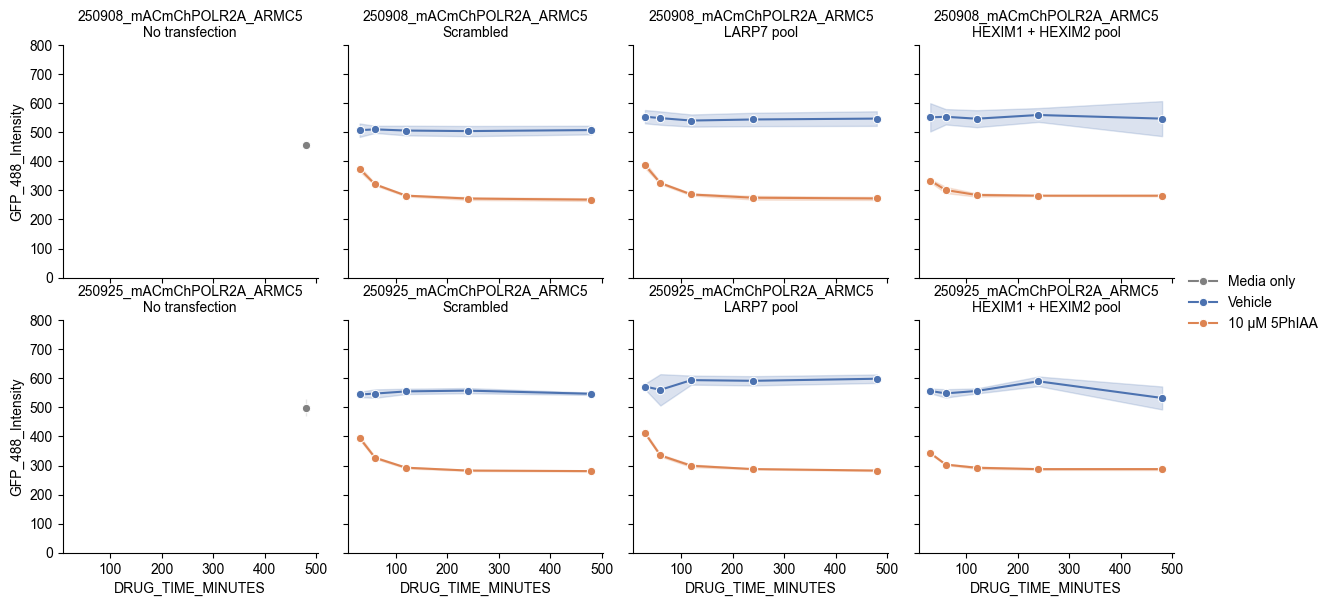

In [9]:
IntensitiesByWell = pd.concat([IntensitiesByWell_Experiment1, IntensitiesByWell_Experiment2])
pal = sns.color_palette(['grey', sns.color_palette('deep')[0], sns.color_palette('deep')[1]])

g = sns.FacetGrid(IntensitiesByWell,
                  col = 'SIRNA', col_order = ['No transfection',
                                              'Scrambled',
                                              'LARP7 pool',
                                              'HEXIM1 + HEXIM2 pool'],
                  row = 'EXPERIMENT',
                  #margin_titles = True,
                  ylim = (0,800))

g.map_dataframe(sns.lineplot,
                x = 'DRUG_TIME_MINUTES',
                y = 'GFP_488_Intensity',
                hue = 'DRUG', hue_order = ['Media only', 'Vehicle', '10 µM 5PhIAA'], palette = pal,
                errorbar = 'sd',
                marker = 'o')

g.set_titles('{row_name}\n{col_name}')
g.add_legend()

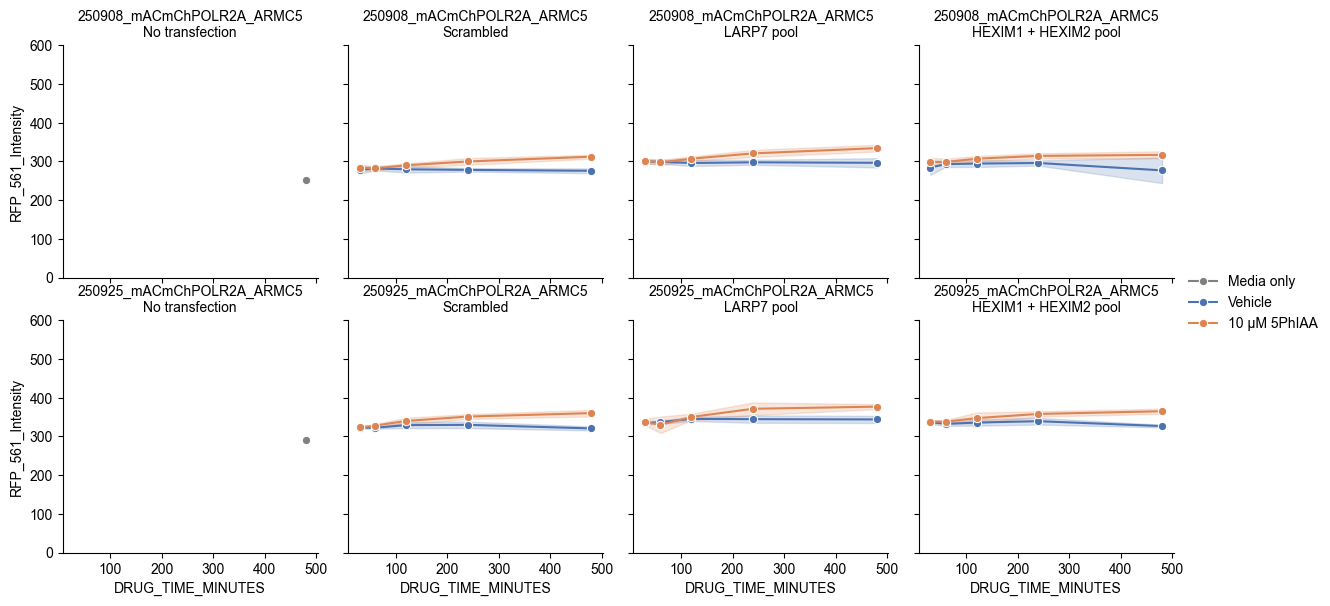

In [10]:
IntensitiesByWell = pd.concat([IntensitiesByWell_Experiment1, IntensitiesByWell_Experiment2])
pal = sns.color_palette(['grey', sns.color_palette('deep')[0], sns.color_palette('deep')[1]])

g = sns.FacetGrid(IntensitiesByWell,
                  col = 'SIRNA', col_order = ['No transfection',
                                              'Scrambled',
                                              'LARP7 pool',
                                              'HEXIM1 + HEXIM2 pool'],
                  row = 'EXPERIMENT',
                  #margin_titles = True,
                  ylim = (0,600))

g.map_dataframe(sns.lineplot,
                x = 'DRUG_TIME_MINUTES',
                y = 'RFP_561_Intensity',
                hue = 'DRUG', hue_order = ['Media only', 'Vehicle', '10 µM 5PhIAA'], palette = pal,
                errorbar = 'sd',
                marker = 'o')

g.set_titles('{row_name}\n{col_name}')
g.add_legend()

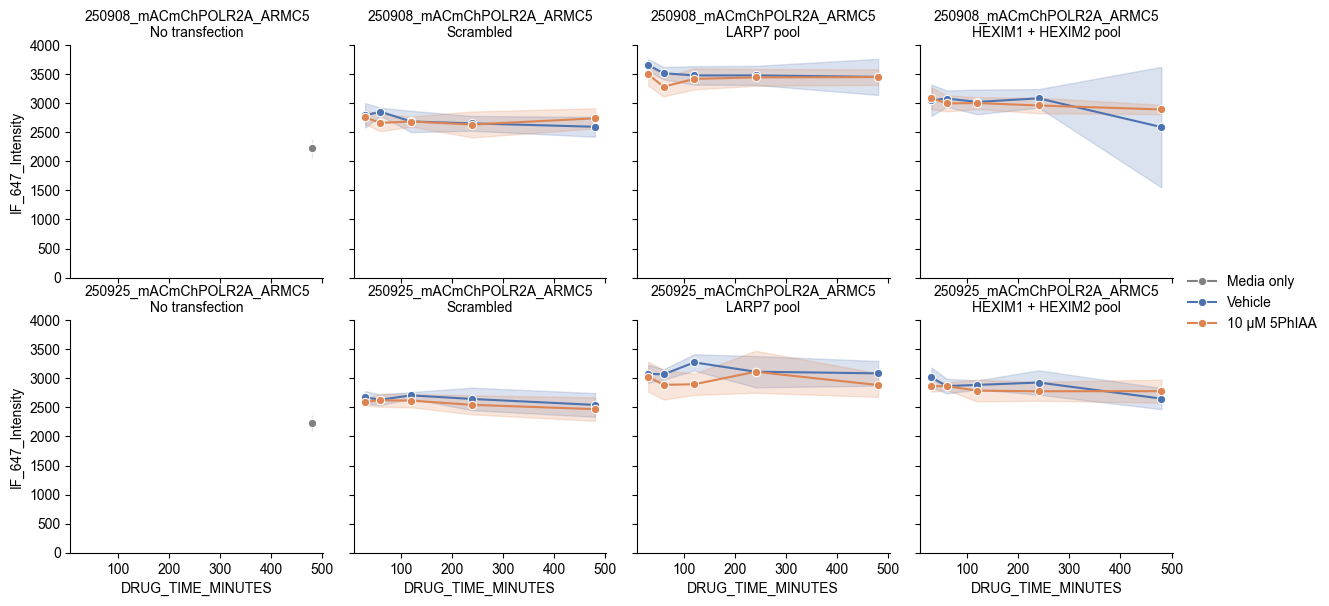

In [11]:
IntensitiesByWell = pd.concat([IntensitiesByWell_Experiment1, IntensitiesByWell_Experiment2])
pal = sns.color_palette(['grey', sns.color_palette('deep')[0], sns.color_palette('deep')[1]])

g = sns.FacetGrid(IntensitiesByWell.query('PRIMARY == "pSer2 Pol II (3E10"'),
                  col = 'SIRNA', col_order = ['No transfection',
                                              'Scrambled',
                                              'LARP7 pool',
                                              'HEXIM1 + HEXIM2 pool'],
                  row = 'EXPERIMENT',
                  #margin_titles = True,
                  ylim = (0,4000))

g.map_dataframe(sns.lineplot,
                x = 'DRUG_TIME_MINUTES',
                y = 'IF_647_Intensity',
                hue = 'DRUG', hue_order = ['Media only', 'Vehicle', '10 µM 5PhIAA'], palette = pal,
                errorbar = 'sd',
                marker = 'o')

g.set_titles('{row_name}\n{col_name}')
g.add_legend()

In [12]:
IntensitiesByWell_Experiment1.query('DRUG == "Vehicle" & DRUG_TIME_MINUTES == 480 & SIRNA == "HEXIM1 + HEXIM2 pool"')

,WELL,IF_647_Intensity,RFP_561_Intensity,GFP_488_Intensity,DAPI_Intensity,NucleusArea,CELL,DRUG,DRUG_TIME_MINUTES,SIRNA,PRIMARY,SECONDARY,TotalNumberCells,EXPERIMENT
25,D08,3263.021862,301.376005,591.759892,697.138805,1389.881579,HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1,Vehicle,480,HEXIM1 + HEXIM2 pool,pSer2 Pol II (3E10,Goat anti-mouse Alexa647,304,250908_mACmChPOLR2A_ARMC5
55,E18,499.889124,212.982752,433.600260,195.260367,496.428571,HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1,Vehicle,480,HEXIM1 + HEXIM2 pool,pSer2 Pol II (3E10,Goat anti-mouse Alexa647,7,250908_mACmChPOLR2A_ARMC5
80,G03,2969.547243,274.218116,535.507271,542.542819,1049.000000,HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1,Vehicle,480,HEXIM1 + HEXIM2 pool,pSer2 Pol II (3E10,Goat anti-mouse Alexa647,73,250908_mACmChPOLR2A_ARMC5
110,H13,3102.169336,299.867623,598.102172,623.642495,1437.320611,HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1,Vehicle,480,HEXIM1 + HEXIM2 pool,pSer2 Pol II (3E10,Goat anti-mouse Alexa647,393,250908_mACmChPOLR2A_ARMC5
145,J08,2934.472049,288.156010,569.385558,582.806720,1373.484716,HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1,Vehicle,480,HEXIM1 + HEXIM2 pool,pSer2 Pol II (3E10,Goat anti-mouse Alexa647,458,250908_mACmChPOLR2A_ARMC5
174,K18,2781.545666,284.989933,556.394631,577.493571,1412.893482,HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1,Vehicle,480,HEXIM1 + HEXIM2 pool,pSer2 Pol II (3E10,Goat anti-mouse Alexa647,629,250908_mACmChPOLR2A_ARMC5


In [13]:
# exclude well E18, very low cell number
IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.query('WELL != "E18"')

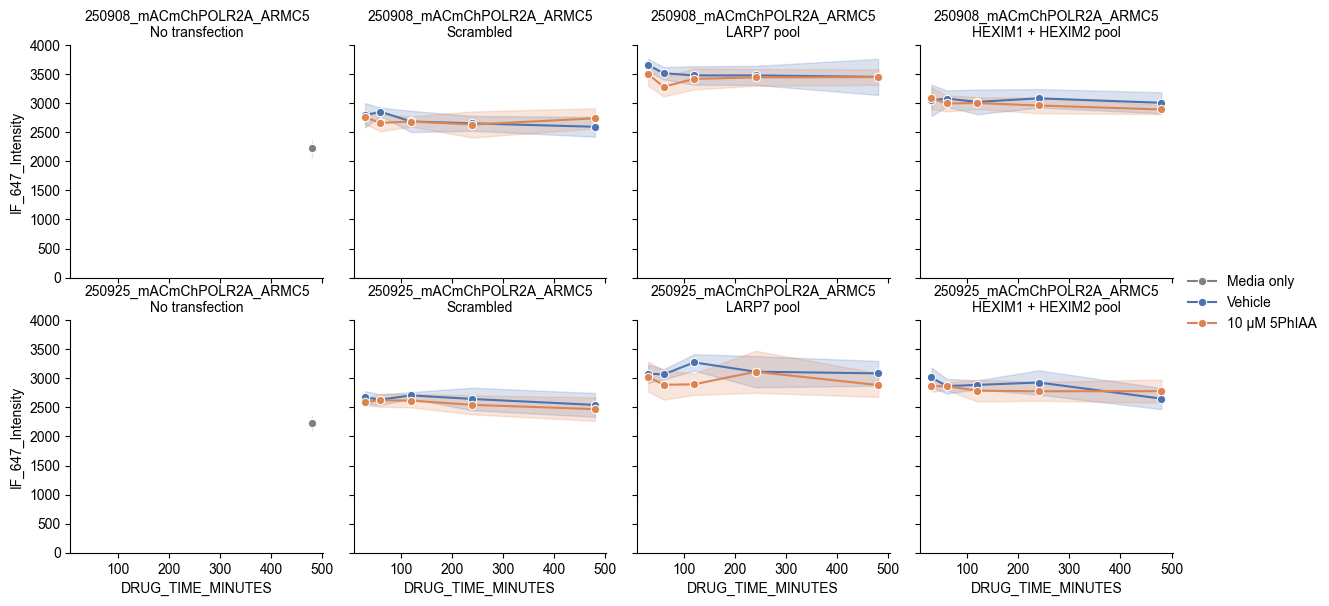

In [14]:
IntensitiesByWell = pd.concat([IntensitiesByWell_Experiment1, IntensitiesByWell_Experiment2])
pal = sns.color_palette(['grey', sns.color_palette('deep')[0], sns.color_palette('deep')[1]])

g = sns.FacetGrid(IntensitiesByWell.query('PRIMARY == "pSer2 Pol II (3E10"'),
                  col = 'SIRNA', col_order = ['No transfection',
                                              'Scrambled',
                                              'LARP7 pool',
                                              'HEXIM1 + HEXIM2 pool'],
                  row = 'EXPERIMENT',
                  #margin_titles = True,
                  ylim = (0,4000))

g.map_dataframe(sns.lineplot,
                x = 'DRUG_TIME_MINUTES',
                y = 'IF_647_Intensity',
                hue = 'DRUG', hue_order = ['Media only', 'Vehicle', '10 µM 5PhIAA'], palette = pal,
                errorbar = 'sd',
                marker = 'o')

g.set_titles('{row_name}\n{col_name}')
g.add_legend()

## background subtract and normalise within each experiment

In [15]:
E1_GFP_Zero = 227.7
E2_GFP_Zero = 236.8

IntensitiesByWell_Experiment1['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment1['GFP_488_Intensity'] - E1_GFP_Zero
IntensitiesByWell_Experiment2['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment2['GFP_488_Intensity'] - E2_GFP_Zero

E1_GFP_NV = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle" & SIRNA == "Scrambled"').GFP_Intensity_BGS.mean()
E2_GFP_NV = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle" & SIRNA == "Scrambled"').GFP_Intensity_BGS.mean()

IntensitiesByWell_Experiment1['GFP_Intensity_FC'] = IntensitiesByWell_Experiment1['GFP_Intensity_BGS'] / E1_GFP_NV
IntensitiesByWell_Experiment2['GFP_Intensity_FC'] = IntensitiesByWell_Experiment2['GFP_Intensity_BGS'] / E2_GFP_NV

In [16]:
E1_RFP_Zero = 144.4
E2_RFP_Zero = 152.4

IntensitiesByWell_Experiment1['RFP_Intensity_BGS'] = IntensitiesByWell_Experiment1['RFP_561_Intensity'] - E1_RFP_Zero
IntensitiesByWell_Experiment2['RFP_Intensity_BGS'] = IntensitiesByWell_Experiment2['RFP_561_Intensity'] - E2_RFP_Zero

E1_RFP_NV = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle" & SIRNA == "Scrambled"').RFP_Intensity_BGS.mean()
E2_RFP_NV = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG == "Vehicle" & SIRNA == "Scrambled"').RFP_Intensity_BGS.mean()

IntensitiesByWell_Experiment1['RFP_Intensity_FC'] = IntensitiesByWell_Experiment1['RFP_Intensity_BGS'] / E1_RFP_NV
IntensitiesByWell_Experiment2['RFP_Intensity_FC'] = IntensitiesByWell_Experiment2['RFP_Intensity_BGS'] / E2_RFP_NV

In [17]:
Experiment1_IF_Zero = IntensitiesByWell_Experiment1.query('PRIMARY == "No primary"')['IF_647_Intensity'].mean()
Experiment2_IF_Zero = IntensitiesByWell_Experiment2.query('PRIMARY == "No primary"')['IF_647_Intensity'].mean()

IntensitiesByWell_Experiment1['IF_647_Intensity_BGS'] = IntensitiesByWell_Experiment1['IF_647_Intensity'] - Experiment1_IF_Zero
IntensitiesByWell_Experiment2['IF_647_Intensity_BGS'] = IntensitiesByWell_Experiment2['IF_647_Intensity'] - Experiment2_IF_Zero

Experiment1_IF_HV = IntensitiesByWell_Experiment1.query('SIRNA == "Scrambled" & DRUG == "Vehicle"')['IF_647_Intensity_BGS'].mean()
Experiment2_IF_HV = IntensitiesByWell_Experiment2.query('SIRNA == "Scrambled" & DRUG == "Vehicle"')['IF_647_Intensity_BGS'].mean()

IntensitiesByWell_Experiment1['IF_647_Intensity_FC'] = IntensitiesByWell_Experiment1['IF_647_Intensity_BGS'] / Experiment1_IF_HV
IntensitiesByWell_Experiment2['IF_647_Intensity_FC'] = IntensitiesByWell_Experiment2['IF_647_Intensity_BGS'] / Experiment2_IF_HV

In [18]:
IntensitiesByWell = pd.concat([IntensitiesByWell_Experiment1, IntensitiesByWell_Experiment2])

## fold vehicle treated wells into 0 timepoint

In [19]:
# exclude untransfected wells to plot only siRNA comparison

In [20]:
IntensitiesByWell.SIRNA.unique()

array(['No transfection', 'HEXIM1 + HEXIM2 pool', 'LARP7 pool',
       'Scrambled'], dtype=object)

In [21]:
IntensitiesByWell = IntensitiesByWell.query('SIRNA != "No transfection"')

In [22]:
IntensitiesByWell.DRUG.unique()

array(['10 µM 5PhIAA', 'Vehicle'], dtype=object)

In [23]:
def time_in_aux(d,t):
    if d == "Vehicle":
        return 0
    elif d == "10 µM 5PhIAA":
        return t

In [24]:
IntensitiesByWell['DRUG_TIME_MINUTES'].unique()

array([480, 240, 120,  60,  30])

In [25]:
IntensitiesByWell['TIME_IN_AUXIN'] = IntensitiesByWell.apply(lambda x: time_in_aux(x['DRUG'], x['DRUG_TIME_MINUTES']), axis = 1)
IntensitiesByWell['TIME_IN_AUXIN'] = (IntensitiesByWell['TIME_IN_AUXIN'].astype('int'))/60

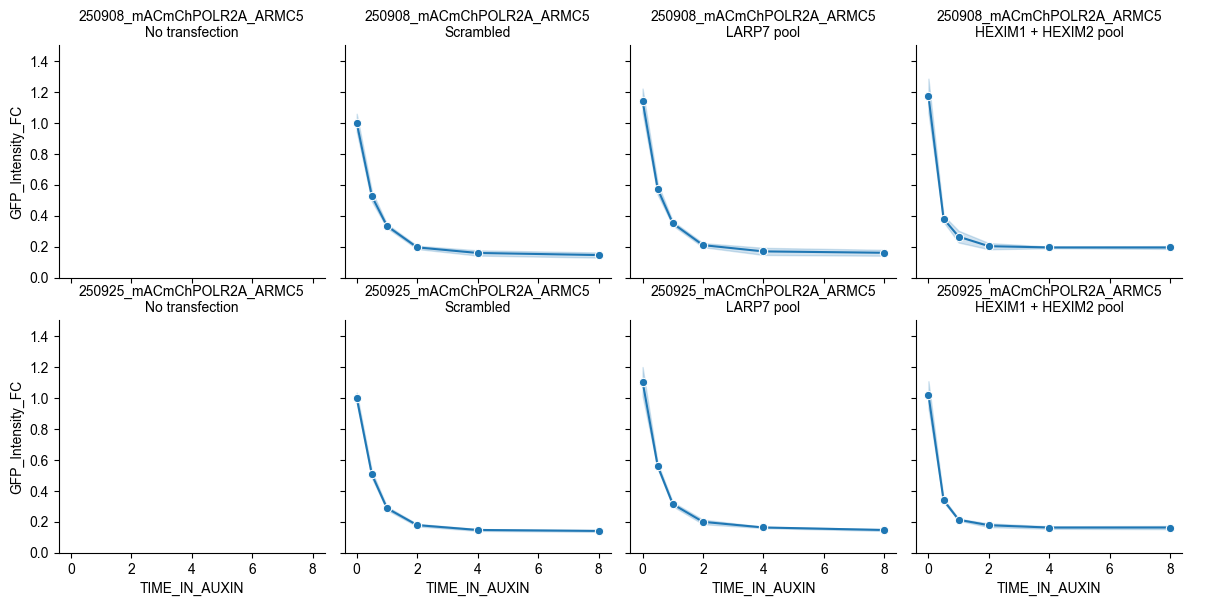

In [26]:
pal = sns.color_palette(['grey', sns.color_palette('deep')[0], sns.color_palette('deep')[1]])

g = sns.FacetGrid(IntensitiesByWell,
                  col = 'SIRNA', col_order = ['No transfection',
                                              'Scrambled',
                                              'LARP7 pool',
                                              'HEXIM1 + HEXIM2 pool'],
                  row = 'EXPERIMENT',
                  #margin_titles = True,
                  ylim = (0,1.5))

g.map_dataframe(sns.lineplot,
                x = 'TIME_IN_AUXIN',
                y = 'GFP_Intensity_FC',
                errorbar = 'sd',
                marker = 'o')

g.set_titles('{row_name}\n{col_name}')
g.add_legend()

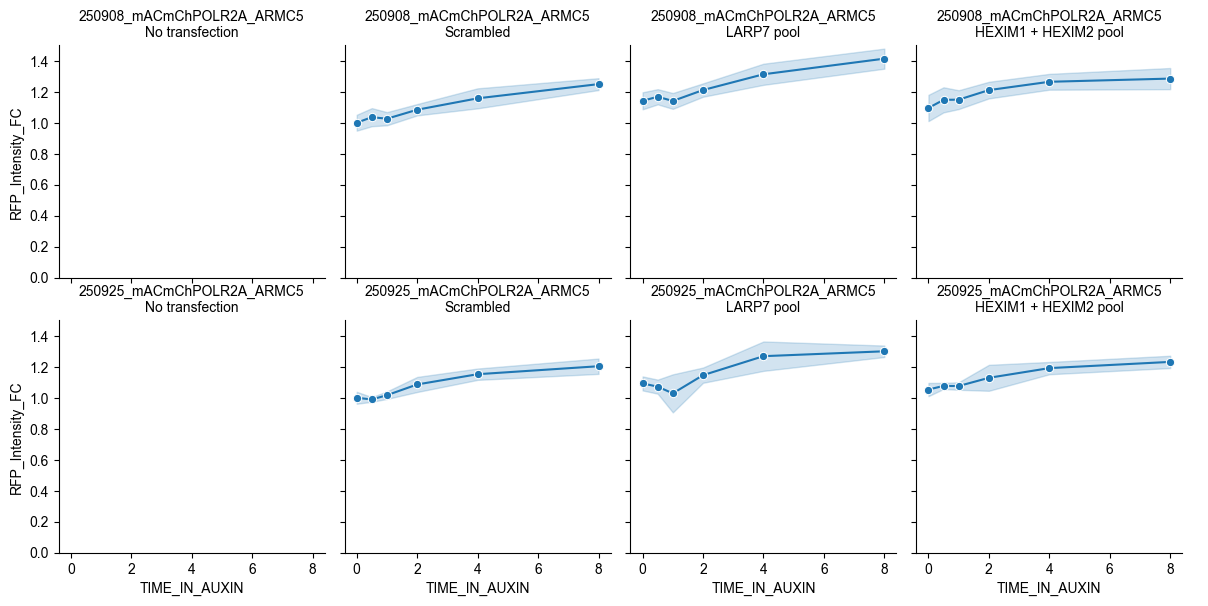

In [27]:
pal = sns.color_palette(['grey', sns.color_palette('deep')[0], sns.color_palette('deep')[1]])

g = sns.FacetGrid(IntensitiesByWell,
                  col = 'SIRNA', col_order = ['No transfection',
                                              'Scrambled',
                                              'LARP7 pool',
                                              'HEXIM1 + HEXIM2 pool'],
                  row = 'EXPERIMENT',
                  #margin_titles = True,
                  ylim = (0,1.5))

g.map_dataframe(sns.lineplot,
                x = 'TIME_IN_AUXIN',
                y = 'RFP_Intensity_FC',
                errorbar = 'sd',
                marker = 'o')

g.set_titles('{row_name}\n{col_name}')
g.add_legend()

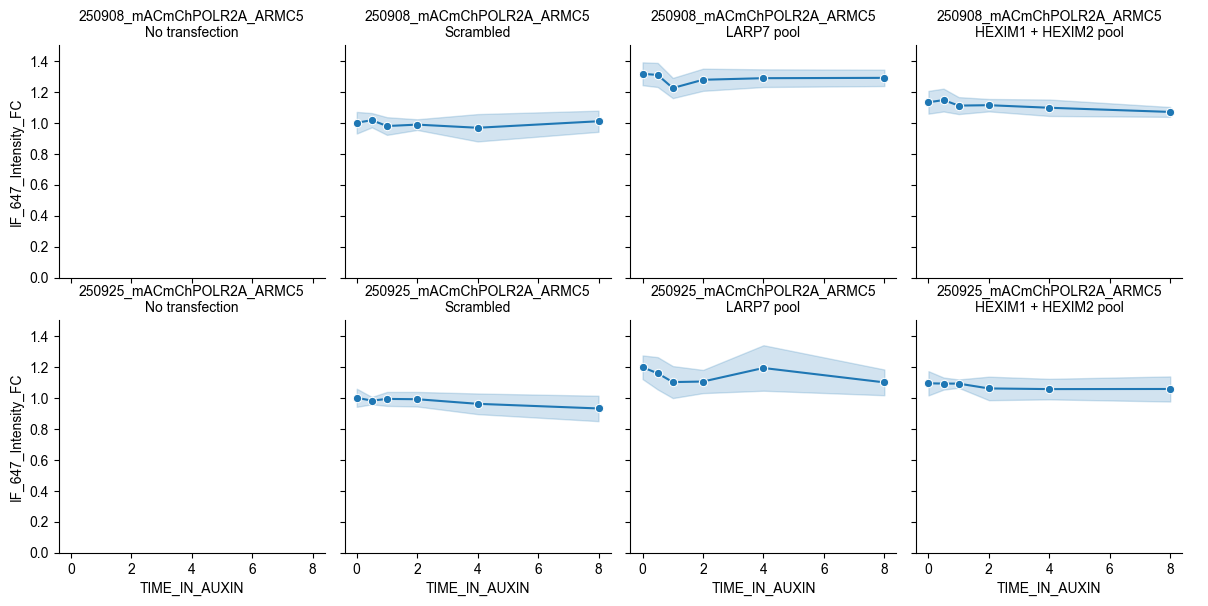

In [28]:
pal = sns.color_palette(['grey', sns.color_palette('deep')[0], sns.color_palette('deep')[1]])

g = sns.FacetGrid(IntensitiesByWell,
                  col = 'SIRNA', col_order = ['No transfection',
                                              'Scrambled',
                                              'LARP7 pool',
                                              'HEXIM1 + HEXIM2 pool'],
                  row = 'EXPERIMENT',
                  #margin_titles = True,
                  ylim = (0,1.5))

g.map_dataframe(sns.lineplot,
                x = 'TIME_IN_AUXIN',
                y = 'IF_647_Intensity_FC',
                errorbar = 'sd',
                marker = 'o')

g.set_titles('{row_name}\n{col_name}')
g.add_legend()

# Plot for manuscript

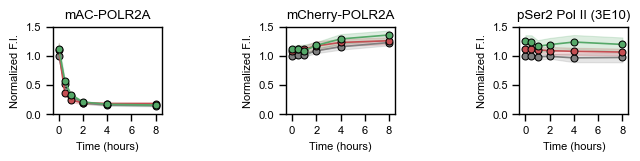

In [41]:
sns.set_context('paper')

pal = sns.color_palette(['grey', sns.color_palette('deep')[3], sns.color_palette('deep')[2]])

f, a = plt.subplots(ncols = 3, figsize = (7,1.5), layout = 'constrained')

a[0].set_title('mAC-POLR2A')
sns.lineplot(IntensitiesByWell,
             x = 'TIME_IN_AUXIN',
             y = 'GFP_Intensity_FC',
             errorbar = 'sd',
             hue = 'SIRNA', hue_order = ['Scrambled', 'HEXIM1 + HEXIM2 pool', 'LARP7 pool'],
             palette = pal,
             marker = 'o', markersize = 5, markeredgecolor = 'black',
             legend = False,
             ax = a[0])

a[1].set_title('mCherry-POLR2A')
sns.lineplot(IntensitiesByWell,
             x = 'TIME_IN_AUXIN',
             y = 'RFP_Intensity_FC',
             errorbar = 'sd',
             hue = 'SIRNA', hue_order = ['Scrambled', 'HEXIM1 + HEXIM2 pool', 'LARP7 pool'],
             palette = pal,
             marker = 'o', markersize = 5, markeredgecolor = 'black',
             legend = False,
             ax = a[1])

a[2].set_title('pSer2 Pol II (3E10)')
sns.lineplot(IntensitiesByWell,
             x = 'TIME_IN_AUXIN',
             y = 'IF_647_Intensity_FC',
             errorbar = 'sd',
             hue = 'SIRNA', hue_order = ['Scrambled', 'HEXIM1 + HEXIM2 pool', 'LARP7 pool'],
             palette = pal,
             marker = 'o', markersize = 5, markeredgecolor = 'black',
             legend = False,
             ax = a[2])


for i in range(3):
    a[i].set_ylim(0,1.5)
    a[i].set_yticks([0, 0.5, 1, 1.5])
    a[i].set_xlim(-0.5,8.5)
    a[i].set_xticks(np.linspace(0,8,5))
    a[i].set_box_aspect(0.8)
    #a[i].set_title(titles[i])
    a[i].set_xlabel('Time (hours)', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].tick_params(axis = 'both', labelsize = 8)

plt.savefig('mACmChPOLR2A_7SK.svg')

In [40]:
pal

[(0.5019607843137255, 0.5019607843137255, 0.5019607843137255),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196)]

# Two way ANOVA on effect of 5PhIAA and siRNA on pSer2 Pol II

In [30]:
Stats_Test = IntensitiesByWell.query('DRUG != "Media only" & SIRNA != "Not transfected" & DRUG_TIME_MINUTES in [0,120]')[['DRUG', 'TIME_IN_AUXIN', 'SIRNA', 'IF_647_Intensity_FC', 'EXPERIMENT']]

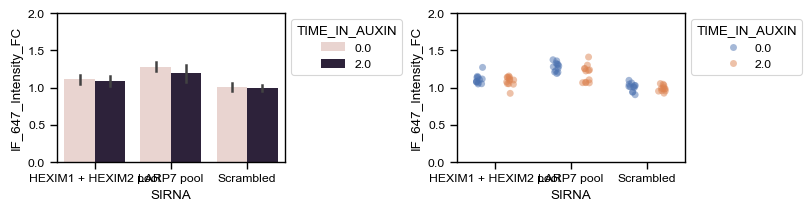

In [31]:
f, a = plt.subplots(figsize = (8,2), ncols = 2, layout = 'constrained')

g = sns.barplot(Stats_Test,
            x = 'SIRNA',
            hue = 'TIME_IN_AUXIN', dodge = True,
            y = 'IF_647_Intensity_FC',
            errorbar = 'sd',
            ax = a[0])
sns.move_legend(g, 'upper left', bbox_to_anchor = (1,1))

g = sns.stripplot(Stats_Test,
            x = 'SIRNA',
            hue = 'TIME_IN_AUXIN', dodge = True, palette = 'deep',
            y = 'IF_647_Intensity_FC',
            ax = a[1],
                  alpha  = 0.5)
sns.move_legend(g, 'upper left', bbox_to_anchor = (1,1))

for i in [0,1]:
    a[i].set_ylim(0,2)

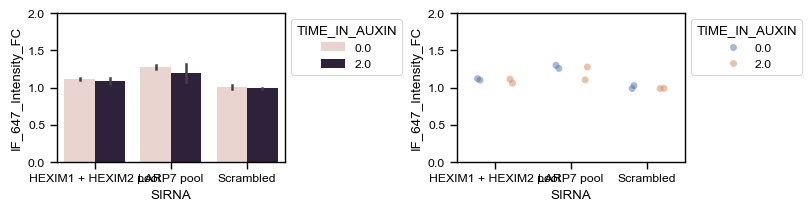

In [32]:
f, a = plt.subplots(figsize = (8,2), ncols = 2, layout = 'constrained')

g = sns.barplot(Stats_Test.groupby(['EXPERIMENT', 'DRUG', 'TIME_IN_AUXIN', 'SIRNA']).mean().reset_index(),
            x = 'SIRNA',
            hue = 'TIME_IN_AUXIN', dodge = True,
            y = 'IF_647_Intensity_FC',
            errorbar = 'sd',
            ax = a[0])
sns.move_legend(g, 'upper left', bbox_to_anchor = (1,1))

g = sns.stripplot(Stats_Test.groupby(['EXPERIMENT', 'DRUG', 'TIME_IN_AUXIN', 'SIRNA']).mean().reset_index(),
            x = 'SIRNA',
            hue = 'TIME_IN_AUXIN', dodge = True, palette = 'deep',
            y = 'IF_647_Intensity_FC',
            ax = a[1],
                  alpha  = 0.5)
sns.move_legend(g, 'upper left', bbox_to_anchor = (1,1))

for i in [0,1]:
    a[i].set_ylim(0,2)

In [33]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
#Stats_Test.to_csv('mACmChPOLR2A_7SK_Veh_5PhIAA_2hours_Scr_HEX12_LARP7_KD.csv')

In [ ]:
model = ols('IF_647_Intensity_FC ~ C(DRUG) + C(SIRNA) + C(SIRNA):C(DRUG)', data=Stats_Test).fit()

In [ ]:
anova_result = sm.stats.anova_lm(model, type=2)

In [ ]:
anova_result

In [ ]:
anova_result['PR(>F)'].tolist()